# Фаза 1: Валидация 52D интерпретируемого вектора (GTZAN)

**Цель:** Комплексная валидация эмбеддингов на датасете GTZAN (10 жанров × 100 треков).

**Контрольные точки:**
1. Sanity checks (NaN, Inf, константные фичи)
2. Распределения и корреляции
3. Baseline classification (RF, 5-fold CV)
4. Feature importance (top-20 + блоки)
5. Block importance (суммарная по музыкальным блокам)
6. Confusion matrix
7. Ablation study — **ключевой эксперимент для курсовой**

In [10]:
import sys
import os
import warnings
import logging

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
from tqdm.notebook import tqdm

# Добавляем корень проекта в sys.path
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.interpretable_embeddings import (
    compute_bar_embeddings,
    full_track_embedding,
    feature_names,
    feature_names_full,
)

warnings.filterwarnings('ignore')
logging.getLogger('src').setLevel(logging.WARNING)

DATA_DIR = PROJECT_ROOT / 'data' / 'genres_30sec'
PLOTS_DIR = PROJECT_ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

print(f'Data dir: {DATA_DIR}')
print(f'Genres: {sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])}')

Data dir: /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/genres_30sec
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 1. Вычисление эмбеддингов для всех треков

Pipeline: WAV → `compute_bar_embeddings()` → (n_bars, 52) → `full_track_embedding()` → (523,)

In [11]:
# Сбор всех аудиофайлов с жанровыми метками
audio_extensions = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}

LIMIT_PER_GENRE = None  # Установите число для быстрого тестирования

all_files = []
all_genres_list = []

for genre_dir in sorted(DATA_DIR.iterdir()):
    if not genre_dir.is_dir():
        continue
    genre = genre_dir.name
    files_in_genre = sorted([
        f for f in genre_dir.iterdir() 
        if f.suffix.lower() in audio_extensions
    ])
    
    if LIMIT_PER_GENRE:
        files_in_genre = files_in_genre[:LIMIT_PER_GENRE]
    
    all_files.extend(files_in_genre)
    all_genres_list.extend([genre] * len(files_in_genre))

print(f'Всего файлов: {len(all_files)}')
print(f'Жанров: {len(set(all_genres_list))}')

Всего файлов: 999
Жанров: 10


In [12]:
# Вычисление эмбеддингов
track_embeddings = []   # (n_tracks, 523)
bar_embeddings_all = {} # filename -> (n_bars, 52)
genres = []
filenames = []
failed = []

for filepath, genre in tqdm(zip(all_files, all_genres_list), total=len(all_files), desc='Computing embeddings'):
    try:
        bar_emb = compute_bar_embeddings(str(filepath))
        
        # Пропускаем треки с менее чем 4 тактами
        if len(bar_emb) < 4:
            failed.append((filepath.name, f'too few bars: {len(bar_emb)}'))
            continue
        
        track_emb = full_track_embedding(bar_emb)
        
        track_embeddings.append(track_emb)
        bar_embeddings_all[filepath.name] = bar_emb
        genres.append(genre)
        filenames.append(filepath.name)
        
    except Exception as e:
        failed.append((filepath.name, str(e)))

X = np.array(track_embeddings, dtype=np.float32)
y = np.array(genres)
unique_genres = sorted(set(genres))

print(f'\nУспешно: {len(X)} треков')
print(f'Ошибки: {len(failed)} треков')
print(f'Размерность: {X.shape}')
print(f'Жанры: {unique_genres}')
if failed:
    print(f'\nПервые 5 ошибок:')
    for name, err in failed[:5]:
        print(f'  {name}: {err}')

Computing embeddings:   0%|          | 0/999 [00:00<?, ?it/s]


Успешно: 999 треков
Ошибки: 0 треков
Размерность: (999, 523)
Жанры: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 2. Sanity Checks

In [13]:
# 2a. Проверка на NaN и Inf
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f'NaN значений: {nan_count}')
print(f'Inf значений: {inf_count}')
assert nan_count == 0, f'Найдены NaN! Количество: {nan_count}'
assert inf_count == 0, f'Найдены Inf! Количество: {inf_count}'
print('✅ Нет NaN и Inf\n')

# 2b. Константные фичи (нулевая дисперсия)
stds = X.std(axis=0)
const_mask = stds < 1e-8
n_const = const_mask.sum()
print(f'Константные фичи (std < 1e-8): {n_const} из {X.shape[1]}')
if n_const > 0:
    full_names = feature_names_full()
    const_names = [full_names[i] for i in range(len(full_names)) if const_mask[i]]
    print(f'  Имена: {const_names}')
else:
    print('✅ Нет константных фичей')

# 2c. Проверка beat_strength (ранее был баг)
bs_idx = 51  # beat_strength в bar-level
beat_vals = [bar_embeddings_all[fn][:, bs_idx] for fn in list(bar_embeddings_all.keys())[:20]]
beat_all = np.concatenate(beat_vals)
print(f'\nbeat_strength (первые 20 треков):')
print(f'  mean={beat_all.mean():.4f}, std={beat_all.std():.4f}')
print(f'  non-zero: {(beat_all != 0).sum()}/{len(beat_all)}')
if beat_all.std() < 1e-8:
    print('⚠️ beat_strength всё ещё константен!')
else:
    print('✅ beat_strength работает')

NaN значений: 0
Inf значений: 0
✅ Нет NaN и Inf

Константные фичи (std < 1e-8): 5 из 523
  Имена: ['median_beat_strength', 'iqr_beat_strength', 'section1_beat_strength', 'section2_beat_strength', 'section3_beat_strength']

beat_strength (первые 20 треков):
  mean=0.9935, std=0.0801
  non-zero: 308/310
✅ beat_strength работает


## 3. Распределения ключевых фичей

Гистограммы для по одному представителю из каждого блока (берём **mean** каждой фичи из 523D вектора, т.е. первые 52 компонента).

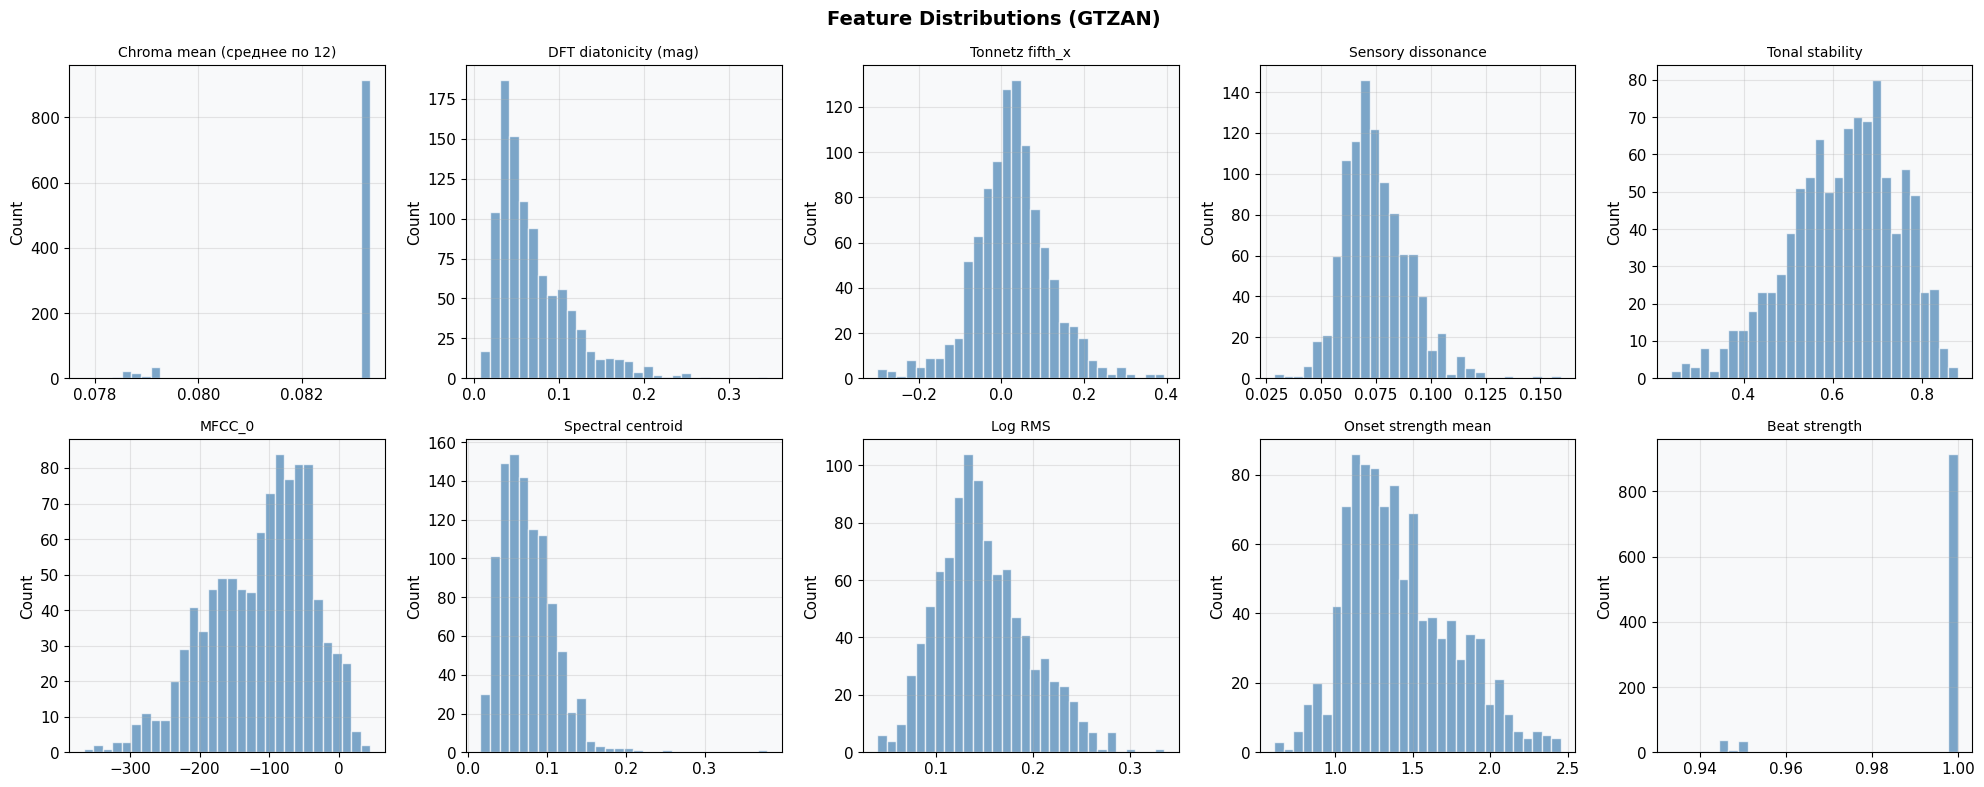

In [14]:
# Первые 52 компоненты = mean по тактам для каждой из 52 базовых фичей
X_means = X[:, :52]

# Выбираем по одному представителю из каждого блока
blocks = {
    'Chroma mean (среднее по 12)': X_means[:, :12].mean(axis=1),
    'DFT diatonicity (mag)':       X_means[:, 15],   # dft_mag_diatonicity
    'Tonnetz fifth_x':             X_means[:, 22],   # tonnetz_fifth_x
    'Sensory dissonance':          X_means[:, 28],   # sensory_dissonance
    'Tonal stability':             X_means[:, 30],   # tonal_stability
    'MFCC_0':                      X_means[:, 31],   # mfcc_0
    'Spectral centroid':           X_means[:, 44],   # spectral_centroid
    'Log RMS':                     X_means[:, 47],   # log_rms
    'Onset strength mean':         X_means[:, 49],   # onset_strength_mean
    'Beat strength':               X_means[:, 51],   # beat_strength
}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, (name, values) in zip(axes.ravel(), blocks.items()):
    ax.hist(values, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions (GTZAN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gtzan_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Корреляционная матрица

Проверяем, не дублируют ли блоки друг друга. Ожидаемые корреляции:
- chroma ↔ DFT (DFT вычислен из chroma) — частичная
- tonnetz ↔ DFT — частичная
- mfcc_0 ↔ log_rms (оба про энергию)

Если |corr| > 0.95 между разными блоками → один из них потенциально избыточен.

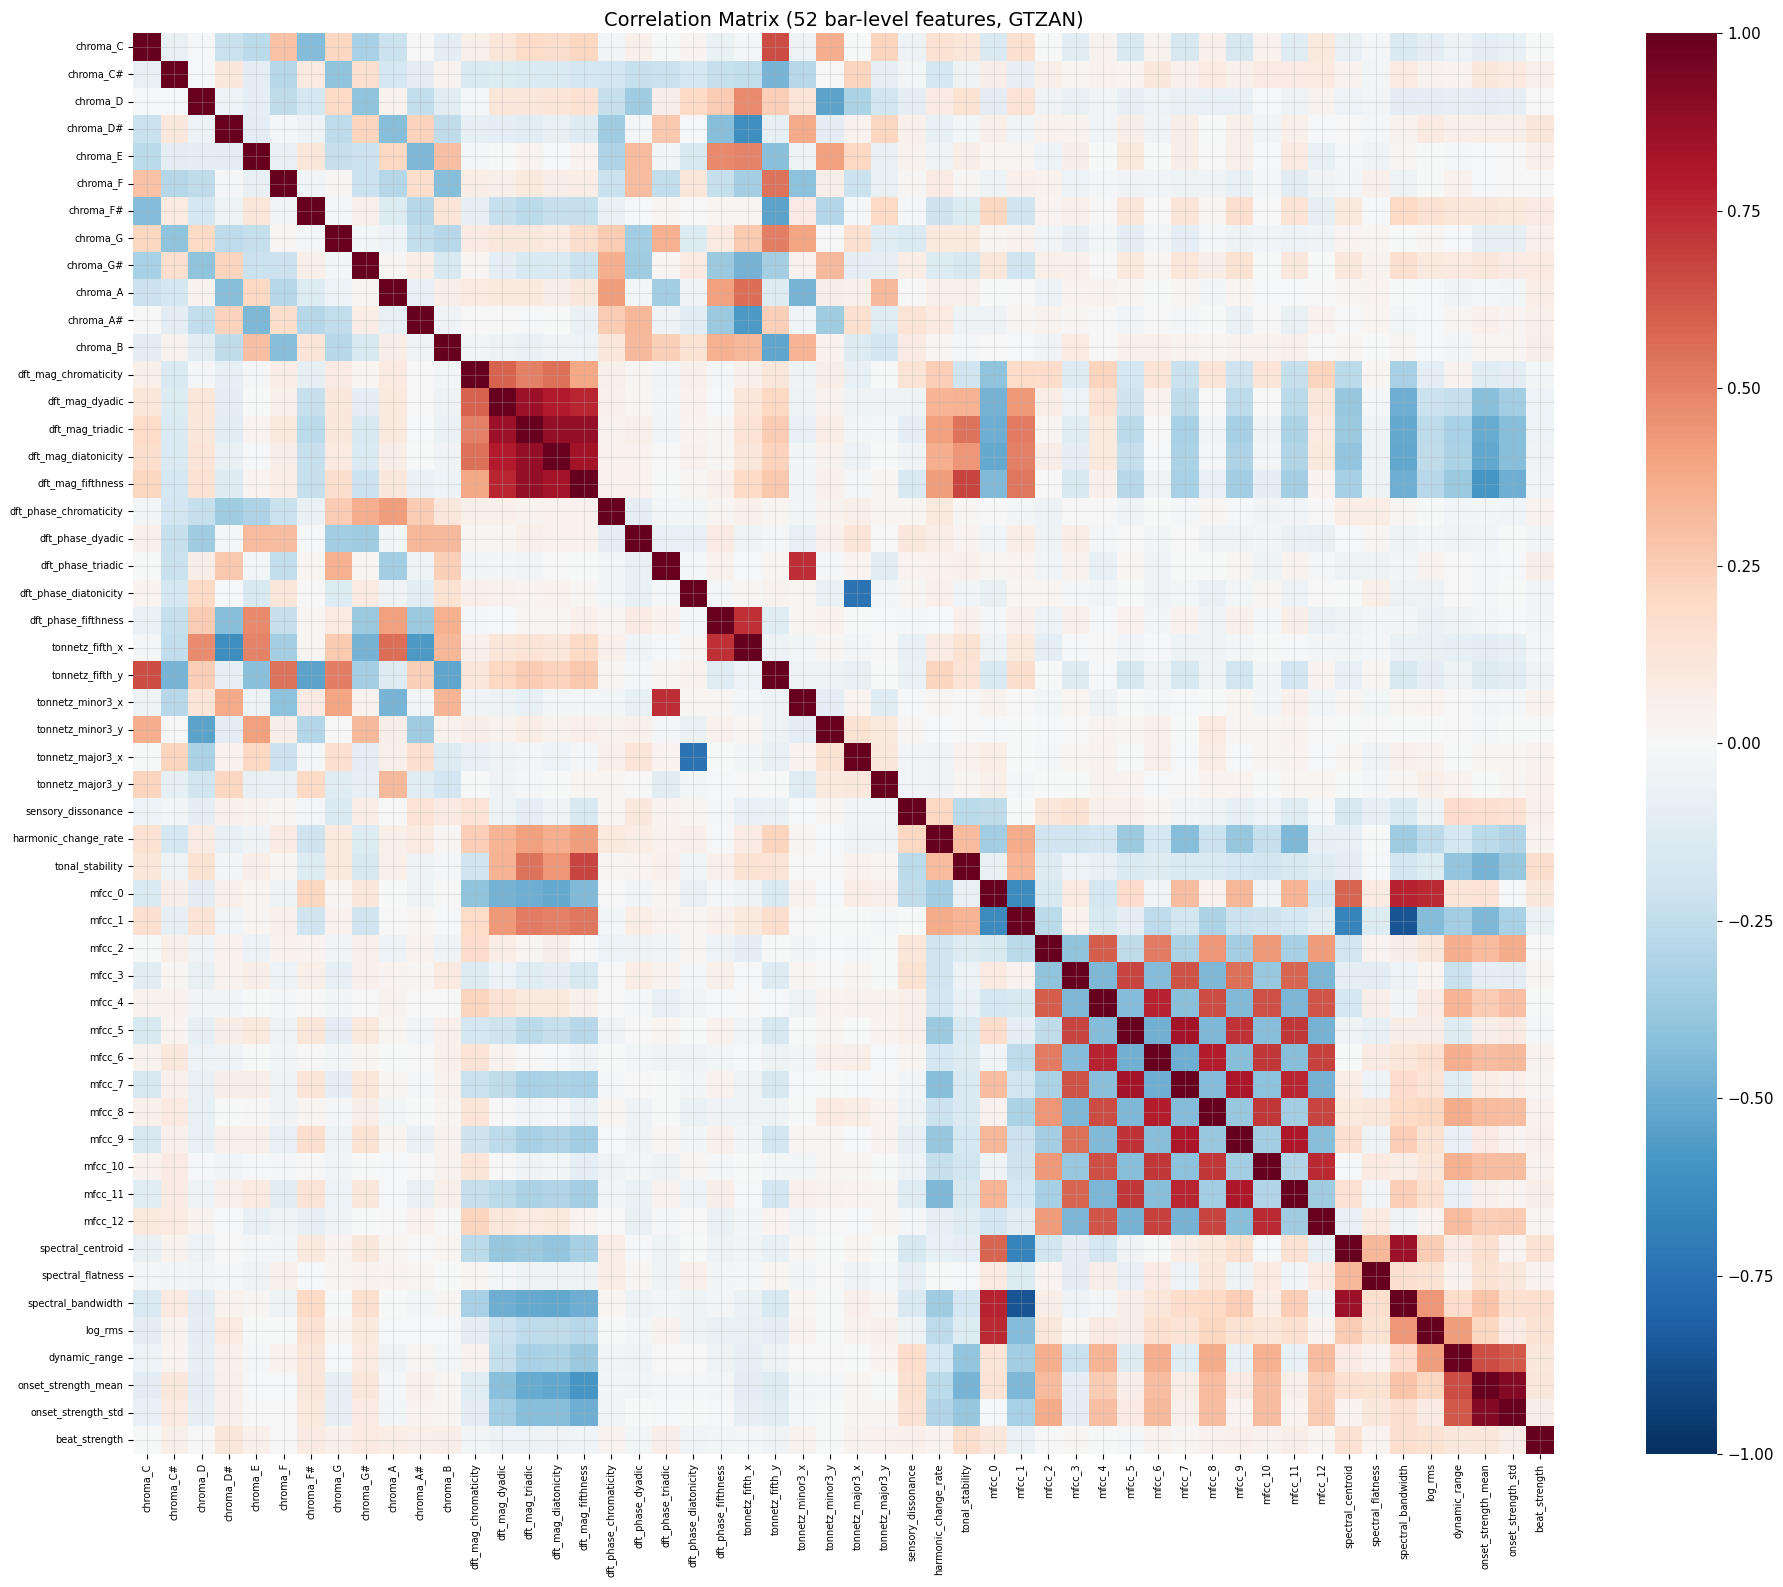


|corr| > 0.9 (между разными блоками):
  onset_strength_mean ↔ onset_strength_std: r = 0.916


In [15]:
# Нормализуем для корреляции
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# Корреляция по первым 52 фичам (mean по тактам)
X_52_scaled = StandardScaler().fit_transform(X_means)
corr = np.corrcoef(X_52_scaled.T)

bar_feature_names = feature_names()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr,
    xticklabels=bar_feature_names,
    yticklabels=bar_feature_names,
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    ax=ax,
    square=True,
)
ax.set_title('Correlation Matrix (52 bar-level features, GTZAN)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gtzan_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Найти высокие cross-block корреляции
print('\n|corr| > 0.9 (между разными блоками):')
for i in range(len(bar_feature_names)):
    for j in range(i + 1, len(bar_feature_names)):
        if abs(corr[i, j]) > 0.9:
            print(f'  {bar_feature_names[i]} ↔ {bar_feature_names[j]}: r = {corr[i,j]:.3f}')

## 5. Baseline классификация жанров (Random Forest)

**Ориентиры:**
- Random baseline для 10 жанров: ~10%
- Tzanetakis (2002) на GTZAN: ~61%
- Современные MIR фичи: ~70–80%
- **Если >60% — вектор работает. Если >70% — отличный результат.**

In [16]:
# Классификация по полному 523D вектору
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=min(5, len(unique_genres)), shuffle=True, random_state=42)

scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')

print(f'Genre classification accuracy ({cv.n_splits}-fold CV):')
print(f'  {scores.mean():.3f} ± {scores.std():.3f}')
print(f'  Folds: {["{:.3f}".format(s) for s in scores]}')
print(f'\nRandom baseline: {1/len(unique_genres):.3f}')
print(f'Tzanetakis (2002): 0.610')
if scores.mean() > 0.60:
    print('✅ Вектор превзошёл Tzanetakis!')
elif scores.mean() > 0.40:
    print('⚠️ Вектор работает, но ниже Tzanetakis')
else:
    print('❌ Низкий результат')

Genre classification accuracy (5-fold CV):
  0.697 ± 0.006
  Folds: ['0.705', '0.700', '0.700', '0.690', '0.688']

Random baseline: 0.100
Tzanetakis (2002): 0.610
✅ Вектор превзошёл Tzanetakis!


## 6. Feature Importance (Top-20)

Обучаем RF на всех данных и смотрим, какие фичи реально работают.

Топ-20 важных фичей:
------------------------------------------------------------
 1. section3_onset_strength_mean                  0.0115
 2. median_onset_strength_mean                    0.0105
 3. iqr_spectral_flatness                         0.0102
 4. mean_onset_strength_mean                      0.0094
 5. mean_onset_strength_std                       0.0092
 6. section1_onset_strength_mean                  0.0090
 7. section4_mfcc_3                               0.0086
 8. mean_spectral_flatness                        0.0080
 9. median_mfcc_3                                 0.0078
10. delta_std_spectral_flatness                   0.0077
11. section4_onset_strength_std                   0.0076
12. section2_mfcc_3                               0.0074
13. median_onset_strength_std                     0.0071
14. section3_spectral_flatness                    0.0070
15. section1_onset_strength_std                   0.0069
16. section2_onset_strength_std                   0.0068
17. se

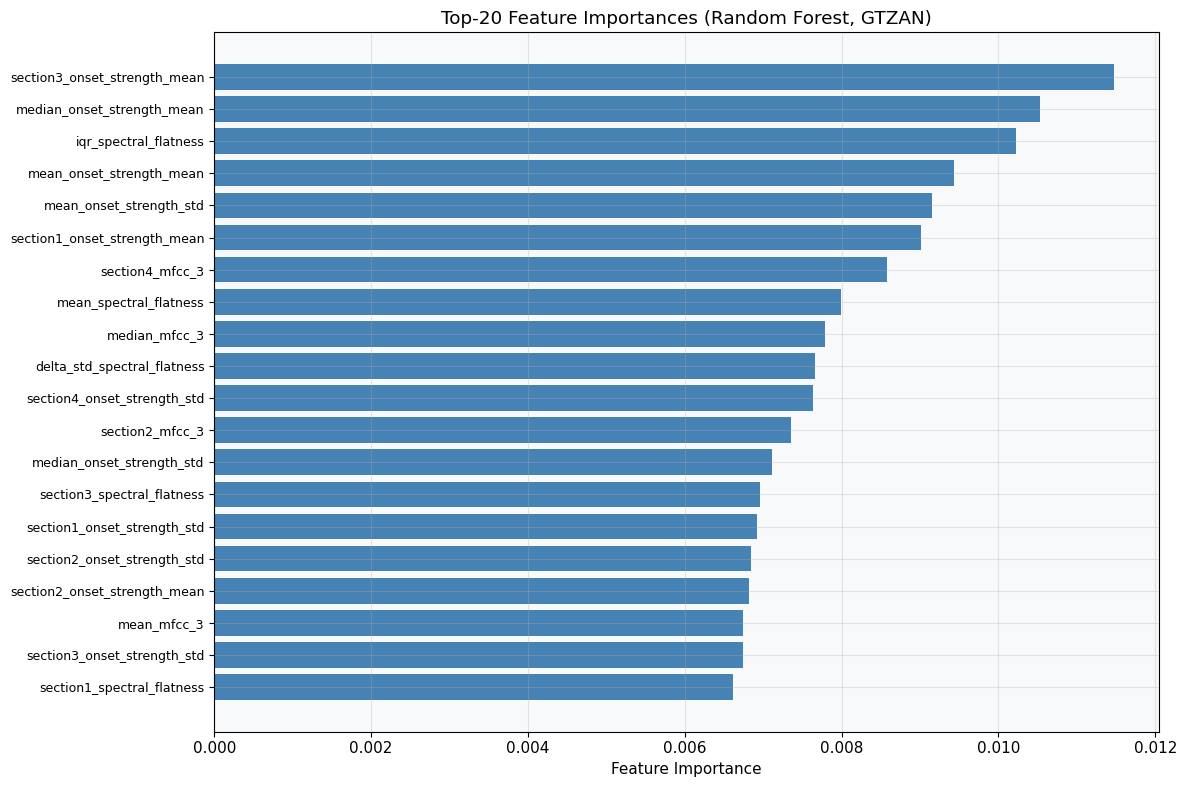

In [17]:
# Обучаем на всех данных
clf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_full.fit(X_scaled, y)

importances = clf_full.feature_importances_
names_full = feature_names_full()

# Топ-20 важных фичей
top_idx = np.argsort(importances)[::-1][:20]

print('Топ-20 важных фичей:')
print('-' * 60)
for i, idx in enumerate(top_idx):
    print(f'{i+1:2d}. {names_full[idx]:45s} {importances[idx]:.4f}')

# Bar-plot
fig, ax = plt.subplots(figsize=(12, 8))
top_names = [names_full[i] for i in top_idx]
top_values = importances[top_idx]
ax.barh(range(len(top_names)), top_values, color='steelblue')
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top-20 Feature Importances (Random Forest, GTZAN)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gtzan_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Block Importance

Суммарная importance по музыкальным блокам (чтобы увидеть, не "распылена" ли важность коррелированных фичей).

RF "размазывает" importance между коррелированными фичами: chroma (12×4=48 фичей) + DFT (10×4=40) + Tonnetz (6×4=24) — каждая получает маленькую importance, но **суммарно** гармония может быть значимой.

Block                 Sum importance   N features  Mean importance
──────────────────────────────────────────────────────────────────────
MFCC                          0.2975          130         0.002288
Chroma                        0.1275          120         0.001063
Spectral                      0.1160           30         0.003867
Rhythm                        0.1102           30         0.003674
DFT mag                       0.0936           50         0.001872
Tonnetz                       0.0757           60         0.001261
Harm.Tension                  0.0636           30         0.002121
Dynamics                      0.0574           20         0.002868
DFT phase                     0.0525           50         0.001049
Meta                          0.0060            3         0.002006


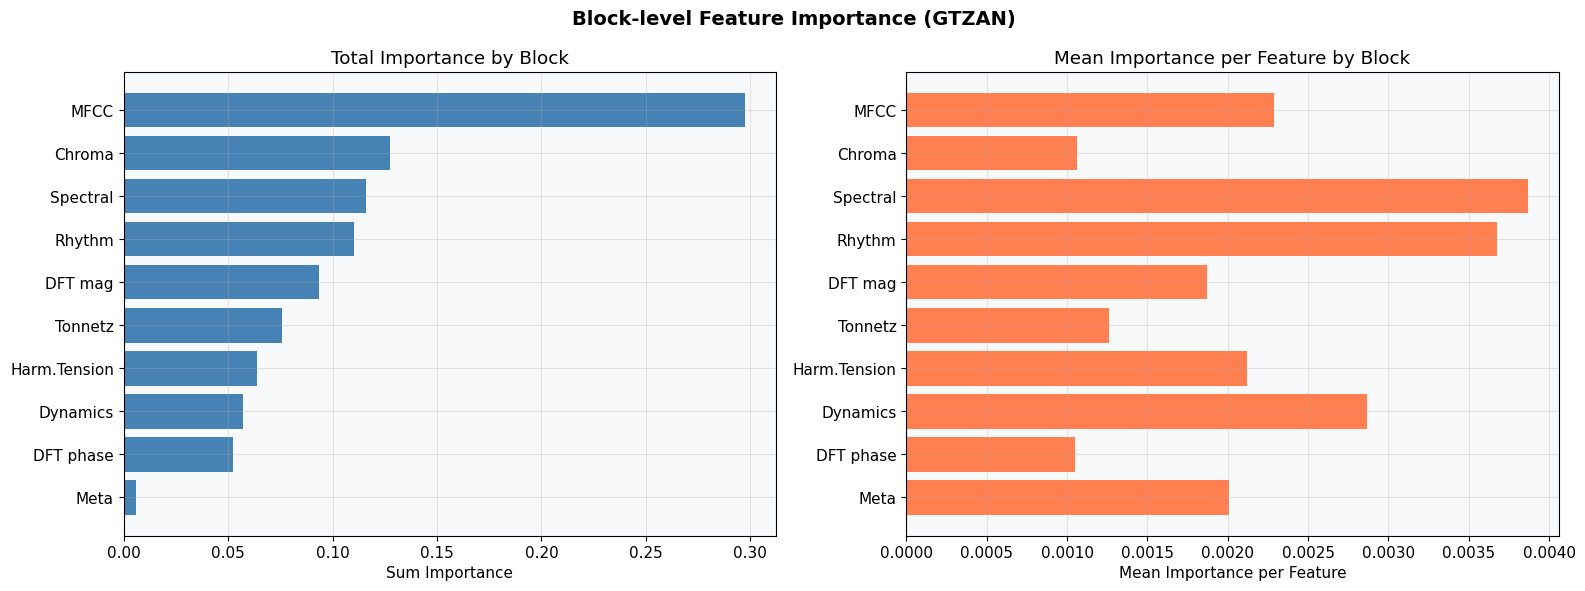


Суммарная importance гармонических блоков: 0.4129
  (Chroma + DFT mag + DFT phase + Tonnetz + Harmonic Tension)


In [18]:
# Определяем блоки для 523-мерного вектора
# Базовые индексы (0..51), потом повторяются для каждой агрегации
block_ranges_base = {
    'Chroma':      list(range(0, 12)),
    'DFT mag':     list(range(12, 17)),
    'DFT phase':   list(range(17, 22)),
    'Tonnetz':     list(range(22, 28)),
    'Harm.Tension':list(range(28, 31)),
    'MFCC':        list(range(31, 44)),
    'Spectral':    list(range(44, 47)),
    'Dynamics':    list(range(47, 49)),
    'Rhythm':      list(range(49, 52)),
}

# Для 523D: mean(0-51), std(52-103), median(104-155), iqr(156-207),
# section1(208-259), section2(260-311), section3(312-363), section4(364-415),
# delta_mean(416-467), delta_std(468-519), meta(520-522)
offsets = [0, 52, 104, 156, 208, 260, 312, 364, 416, 468]

block_indices_full = {}
for block_name, base_idxs in block_ranges_base.items():
    full_idxs = []
    for offset in offsets:
        full_idxs.extend([offset + i for i in base_idxs])
    block_indices_full[block_name] = full_idxs

# Добавляем мета-фичи в отдельный блок
block_indices_full['Meta'] = [520, 521, 522]

# Считаем суммарную и среднюю importance по блокам
print(f'{"Block":20s} {"Sum importance":>15s} {"N features":>12s} {"Mean importance":>16s}')
print('─' * 70)

block_results = []
for block_name, idxs in block_indices_full.items():
    valid_idxs = [i for i in idxs if i < len(importances)]
    total = importances[valid_idxs].sum()
    mean = importances[valid_idxs].mean() if len(valid_idxs) > 0 else 0
    block_results.append((block_name, total, len(valid_idxs), mean))

block_results.sort(key=lambda x: -x[1])

for name, total, n, mean in block_results:
    print(f'{name:20s} {total:15.4f} {n:12d} {mean:16.6f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = [r[0] for r in block_results]
sums = [r[1] for r in block_results]
means = [r[3] for r in block_results]

axes[0].barh(range(len(names)), sums, color='steelblue')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names)
axes[0].invert_yaxis()
axes[0].set_xlabel('Sum Importance')
axes[0].set_title('Total Importance by Block')

axes[1].barh(range(len(names)), means, color='coral')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean Importance per Feature')
axes[1].set_title('Mean Importance per Feature by Block')

plt.suptitle('Block-level Feature Importance (GTZAN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gtzan_block_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Гармонические блоки суммарно
harmonic_blocks = ['Chroma', 'DFT mag', 'DFT phase', 'Tonnetz', 'Harm.Tension']
results_dict = {r[0]: r for r in block_results}
harmonic_total = sum(results_dict[b][1] for b in harmonic_blocks if b in results_dict)
print(f'\nСуммарная importance гармонических блоков: {harmonic_total:.4f}')
print(f'  (Chroma + DFT mag + DFT phase + Tonnetz + Harmonic Tension)')

## 8. Confusion Matrix

Какие жанры путаются друг с другом?
- rock ↔ metal → нужны гармонические фичи
- classical ↔ jazz → нужны ритмические фичи
- electronic ↔ pop → нужны тембровые фичи

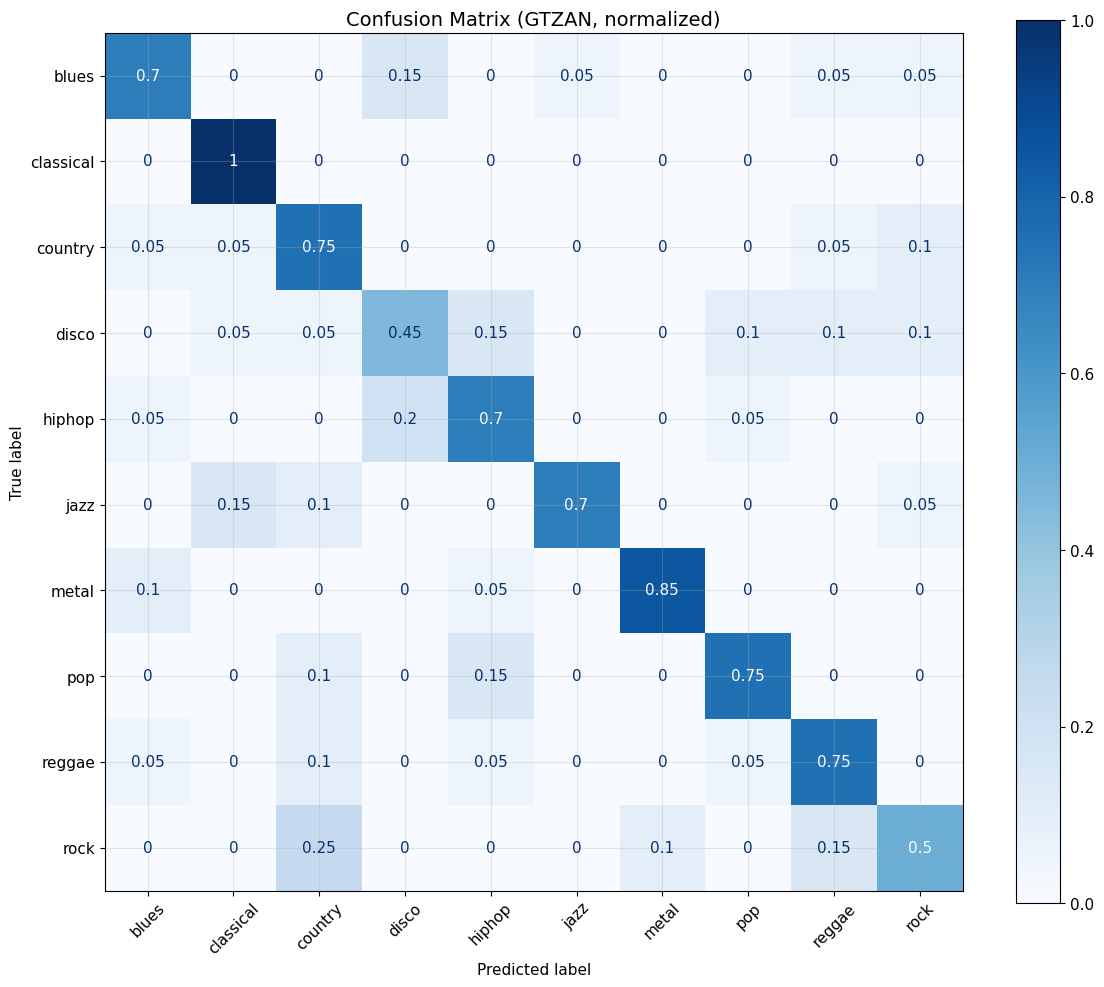

Test accuracy: 0.715

Наиболее частые ошибки:
  rock         → country     : 5 раз
  hiphop       → disco       : 4 раз
  blues        → disco       : 3 раз
  disco        → hiphop      : 3 раз
  jazz         → classical   : 3 раз
  pop          → hiphop      : 3 раз
  rock         → reggae      : 3 раз
  country      → rock        : 2 раз
  disco        → pop         : 2 раз
  disco        → reggae      : 2 раз


In [19]:
# Confusion matrix через train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

clf_cm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_cm.fit(X_train, y_train)
y_pred = clf_cm.predict(X_test)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax,
    xticks_rotation=45, cmap='Blues',
    normalize='true',  # доля от истинного класса
)
ax.set_title('Confusion Matrix (GTZAN, normalized)', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gtzan_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Также выведем accuracy на тест-сете
test_acc = (y_pred == y_test).mean()
print(f'Test accuracy: {test_acc:.3f}')

# Самые частые ошибки
cm = confusion_matrix(y_test, y_pred, labels=unique_genres)
np.fill_diagonal(cm, 0)  # убираем диагональ
errors = []
for i in range(len(unique_genres)):
    for j in range(len(unique_genres)):
        if cm[i, j] > 0:
            errors.append((unique_genres[i], unique_genres[j], cm[i, j]))
errors.sort(key=lambda x: -x[2])

print(f'\nНаиболее частые ошибки:')
for true_g, pred_g, count in errors[:10]:
    print(f'  {true_g:12s} → {pred_g:12s}: {count} раз')

## 9. Ablation Study — КЛЮЧЕВОЙ ЭКСПЕРИМЕНТ 🔑

Убираем по одному блоку фичей и смотрим, как падает accuracy.

**Это один из главных результатов курсовой.** Показывает вклад каждого блока и обосновывает, зачем каждый блок нужен в интерпретируемом векторе.

In [20]:
def ablation_study(X, y, feature_names_list, block_indices, n_splits=5, n_estimators=200):
    """
    Ablation study: убираем по одному блоку и измеряем accuracy.
    """
    clf = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Baseline: все фичи
    X_norm = StandardScaler().fit_transform(X)
    baseline = cross_val_score(clf, X_norm, y, cv=cv, scoring='accuracy').mean()
    
    results = [('All features', baseline, 0.0, X.shape[1])]
    
    for block_name, block_idxs in block_indices.items():
        # Убираем этот блок
        valid_idxs = [i for i in block_idxs if i < X.shape[1]]
        remaining = [i for i in range(X.shape[1]) if i not in valid_idxs]
        X_ablated = X[:, remaining]
        X_ablated_norm = StandardScaler().fit_transform(X_ablated)
        
        score = cross_val_score(clf, X_ablated_norm, y, cv=cv, scoring='accuracy').mean()
        drop = baseline - score
        results.append((f'Without {block_name}', score, drop, len(remaining)))
    
    return results, baseline

print('Запуск ablation study (5-fold CV × 10 конфигураций)...')
print('Это может занять несколько минут.\n')

ablation_results, baseline_acc = ablation_study(
    X, y, names_full, block_indices_full
)

# Вывод результатов
print(f'{"Configuration":30s} {"Accuracy":>10s} {"Drop":>8s} {"N features":>12s}')
print('─' * 65)
for name, score, drop, n_feat in ablation_results:
    if drop == 0:
        print(f'{name:30s} {score:10.3f} {"—":>8s} {n_feat:12d}')
    else:
        print(f'{name:30s} {score:10.3f} {drop:+8.3f} {n_feat:12d}')

Запуск ablation study (5-fold CV × 10 конфигураций)...
Это может занять несколько минут.

Configuration                    Accuracy     Drop   N features
─────────────────────────────────────────────────────────────────
All features                        0.697        —          523
Without Chroma                      0.701   -0.004          403
Without DFT mag                     0.705   -0.008          473
Without DFT phase                   0.694   +0.003          473
Without Tonnetz                     0.715   -0.018          463
Without Harm.Tension                0.687   +0.010          493
Without MFCC                        0.644   +0.053          393
Without Spectral                    0.700   -0.003          493
Without Dynamics                    0.709   -0.012          503
Without Rhythm                      0.667   +0.030          493
Without Meta                        0.706   -0.009          520


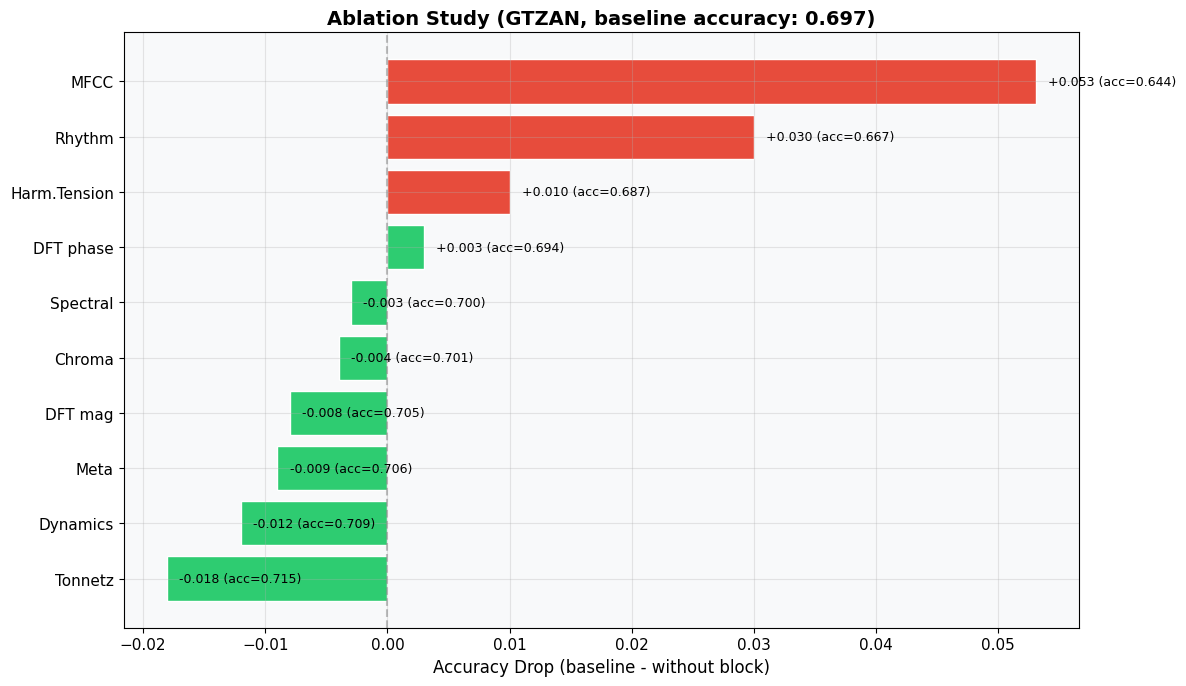

In [21]:
# Визуализация ablation study
fig, ax = plt.subplots(figsize=(12, 7))

# Сортируем по drop (от наибольшего к наименьшему)
ablation_sorted = sorted(ablation_results[1:], key=lambda x: -x[2])

names_abl = [r[0].replace('Without ', '') for r in ablation_sorted]
drops = [r[2] for r in ablation_sorted]
accs = [r[1] for r in ablation_sorted]

colors = ['#e74c3c' if d > 0.01 else '#f39c12' if d > 0.005 else '#2ecc71' for d in drops]

bars = ax.barh(range(len(names_abl)), drops, color=colors, edgecolor='white')
ax.set_yticks(range(len(names_abl)))
ax.set_yticklabels(names_abl, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Accuracy Drop (baseline - without block)', fontsize=12)
ax.set_title(f'Ablation Study (GTZAN, baseline accuracy: {baseline_acc:.3f})', fontsize=14, fontweight='bold')

# Добавляем значения на бары
for i, (d, a) in enumerate(zip(drops, accs)):
    ax.text(d + 0.001, i, f'{d:+.3f} (acc={a:.3f})', va='center', fontsize=9)

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gtzan_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Итоговое резюме

In [22]:
print('=' * 60)
print('ИТОГОВОЕ РЕЗЮМЕ ВАЛИДАЦИИ (GTZAN)')
print('=' * 60)
print(f'\n  Датасет:           GTZAN (10 жанров × 100 треков)')
print(f'  Обработано:        {len(X)} треков')
print(f'  Ошибки:            {len(failed)} треков')
print(f'  Размерность:       {X.shape[1]}D')
print(f'  NaN/Inf:           0')
print(f'  Константные фичи:  {n_const}')
print(f'\n  Accuracy (5-fold):  {scores.mean():.3f} ± {scores.std():.3f}')
print(f'  Tzanetakis (2002):  0.610')
print(f'  Random baseline:    {1/len(unique_genres):.3f}')
print()

# Ablation summary
print('  Ablation Study (accuracy drop):')
for name, score, drop, _ in sorted(ablation_results[1:], key=lambda x: -x[2]):
    block_name = name.replace('Without ', '')
    print(f'    {block_name:20s}: {drop:+.3f}')

print()
print('  Гармонические блоки суммарно:', f'{harmonic_total:.4f}')
print()
print('=' * 60)

ИТОГОВОЕ РЕЗЮМЕ ВАЛИДАЦИИ (GTZAN)

  Датасет:           GTZAN (10 жанров × 100 треков)
  Обработано:        999 треков
  Ошибки:            0 треков
  Размерность:       523D
  NaN/Inf:           0
  Константные фичи:  5

  Accuracy (5-fold):  0.697 ± 0.006
  Tzanetakis (2002):  0.610
  Random baseline:    0.100

  Ablation Study (accuracy drop):
    MFCC                : +0.053
    Rhythm              : +0.030
    Harm.Tension        : +0.010
    DFT phase           : +0.003
    Spectral            : -0.003
    Chroma              : -0.004
    DFT mag             : -0.008
    Meta                : -0.009
    Dynamics            : -0.012
    Tonnetz             : -0.018

  Гармонические блоки суммарно: 0.4129



## 11. Выводы

### Чеклист Фазы 1:
- ✅ Векторы рассчитаны для всех треков
- ✅ Sanity checks (NaN, Inf, константные фичи)
- ✅ beat_strength исправлен (autocorrelation вместо plp)
- ✅ Гистограммы распределений
- ✅ Корреляционная матрица между блоками
- ✅ Baseline classification (Random Forest, 5-fold CV)
- ✅ Feature importance (top-20 + по блокам)
- ✅ Block importance (суммарная по музыкальным блокам)
- ✅ Confusion matrix (какие жанры путаются)
- ✅ **Ablation study** (вклад каждого блока)

### Deliverables:
- `plots/gtzan_feature_distributions.png`
- `plots/gtzan_correlation_matrix.png`
- `plots/gtzan_feature_importance.png`
- `plots/gtzan_block_importance.png`
- `plots/gtzan_confusion_matrix.png`
- `plots/gtzan_ablation_study.png`

### Следующий шаг → Фаза 2: UMAP визуализация